# Preprocesamiento y limpieza datasets

## 3. Datos estructurados

Los datos estructurados son aquellos que ya se presentan en formato tabular
(filas × columnas), lo que simplifica su carga. Sin embargo, 
cada dataset presenta sus propios problemas de calidad
que deben detectarse y documentarse antes de usarlos en modelos.

**Archivos a tratar:**
| Archivo | Registros est. | Clave principal | Problema central |
|---|---|---|---|
| `produccion_agricola.csv` | ~1.200 | pais + cultivo + anio | Outliers en rendimiento; validación interna |
| `produccion_ganadera.csv` | ~600 | pais + tipo_ganado + anio | Ceros estructurales; outliers en emisiones |
| `precios_mercado.csv` | ~720 | fecha + pais + producto | Serie temporal irregular; ordinal en tendencia |
| `imagenes_metadata.csv` | ~90 | imagen_id | Lista en bandas; validación rangos físicos NDVI |

**Herramienta principal:** `pandas` con apoyo de `numpy` para validaciones
numéricas y `matplotlib`/`seaborn` para visualización de outliers.

**Criterio general aplicado en esta sección:**
- Nulos reales vs. nulos estructurales.
- Outliers documentados, no eliminados automáticamente.
- Toda decisión de transformación queda justificada en celda Markdown previa.

### 3.1. produccion_agricola.csv

**Estructura del dataset:**
- **Granularidad:** un registro por combinación única `pais × cultivo × año`
- **11 columnas:** identificadores (pais, codigo_iso, region, cultivo, anio)
  + 5 métricas productivas + tendencia_5_anios

#### Celda 1 - Carga y exploración inicial

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_agr = pd.read_csv('../../data/raw/structured/produccion_agricola.csv')

print(f"✅ produccion_agricola.csv cargado correctamente")
print(f"📐 Dimensiones: {df_agr.shape}")
print(f"\n📋 Columnas y tipos:")
print(df_agr.dtypes)
print(f"\n🔍 Primeras 3 filas:")
display(df_agr.head(3))

print(f"\n{'='*45}")
print(f"  CARDINALIDAD DE VARIABLES CLAVE")
print(f"{'='*45}")
print(f"  Países únicos  : {df_agr['pais'].nunique()} → {sorted(df_agr['pais'].unique())}")
print(f"  Cultivos únicos: {df_agr['cultivo'].nunique()} → {sorted(df_agr['cultivo'].unique())}")
print(f"  Rango temporal : {df_agr['anio'].min()} → {df_agr['anio'].max()}")
print(f"  Registros/país : {df_agr.groupby('pais').size().to_dict()}")

print(f"\n📊 Estadísticas descriptivas:")
display(df_agr.describe().round(3))

✅ produccion_agricola.csv cargado correctamente
📐 Dimensiones: (1200, 11)

📋 Columnas y tipos:
pais                        str
codigo_iso                  str
region                      str
cultivo                     str
anio                      int64
superficie_hectareas      int64
rendimiento_ton_ha      float64
produccion_ton            int64
fertilizantes_kg_ha       int64
agua_riego_m3_ha          int64
tendencia_5_anios       float64
dtype: object

🔍 Primeras 3 filas:


,pais,codigo_iso,region,cultivo,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios
0,Argentina,ARG,América del Sur,Soja,2011,4703643,2.22,10465461,105,4811,0.000536
1,Argentina,ARG,América del Sur,Maíz,2011,3371781,8.45,28485921,164,5557,0.030943
2,Argentina,ARG,América del Sur,Cebada,2011,1661577,2.77,4596917,105,6514,-0.039779



  CARDINALIDAD DE VARIABLES CLAVE
  Países únicos  : 15 → ['Alemania', 'Argentina', 'Australia', 'Brasil', 'Canadá', 'China', 'España', 'Estados Unidos', 'Francia', 'India', 'Italia', 'Kenia', 'México', 'Nueva Zelanda', 'Rusia']
  Cultivos únicos: 10 → ['Algodón', 'Arroz', 'Café', 'Caña de azúcar', 'Cebada', 'Girasol', 'Maíz', 'Soja', 'Trigo', 'Té']
  Rango temporal : 2011 → 2020
  Registros/país : {'Alemania': 80, 'Argentina': 80, 'Australia': 80, 'Brasil': 80, 'Canadá': 80, 'China': 80, 'España': 80, 'Estados Unidos': 80, 'Francia': 80, 'India': 80, 'Italia': 80, 'Kenia': 80, 'México': 80, 'Nueva Zelanda': 80, 'Rusia': 80}

📊 Estadísticas descriptivas:


,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios
count,1200.000,1.200000e+03,1200.000,1.200000e+03,1200.000,1200.000,1200.000
mean,2015.500,2.351555e+06,12.878,5.329724e+07,172.769,5464.924,-0.001
std,2.873,2.379629e+06,27.419,1.557934e+08,72.206,2598.509,0.029
min,2011.000,9.770000e+02,0.430,2.775000e+03,50.000,1001.000,-0.050
25%,2013.000,4.013445e+05,2.228,9.711170e+05,109.750,3184.250,-0.025
50%,2015.500,1.589487e+06,3.500,5.880648e+06,173.000,5526.500,-0.001
75%,2018.000,3.447043e+06,5.932,1.745015e+07,234.250,7746.250,0.024
max,2020.000,1.263063e+07,158.450,1.154381e+09,300.000,9998.000,0.050


Tipos de variables adecuados

#### Celda 2 - Análisis nulos y duplicados

In [14]:
print(f"{'='*45}")
print(f"  NULOS")
print(f"{'='*45}")
nulos = df_agr.isnull().sum()
nulos_pct = (nulos / len(df_agr) * 100).round(2)
resumen_nulos = pd.DataFrame({'n_nulos': nulos, 'porcentaje': nulos_pct})
print(resumen_nulos[resumen_nulos['n_nulos'] > 0].to_string()
      if resumen_nulos['n_nulos'].sum() > 0
      else "  ✅ Sin nulos detectados")

print(f"\n{'='*45}")
print(f"  DUPLICADOS")
print(f"{'='*45}")
n_dup = df_agr.duplicated().sum()
print(f"  Filas duplicadas totales : {n_dup}")

# Duplicados por clave compuesta
n_dup_clave = df_agr.duplicated(subset=['pais','cultivo','anio']).sum()
print(f"  Duplicados en clave pais+cultivo+anio: {n_dup_clave}")
if n_dup_clave > 0:
    print(df_agr[df_agr.duplicated(subset=['pais','cultivo','anio'], keep=False)]
          .sort_values(['pais','cultivo','anio']))

  NULOS
  ✅ Sin nulos detectados

  DUPLICADOS
  Filas duplicadas totales : 0
  Duplicados en clave pais+cultivo+anio: 0


#### Celda 3 - Detección outliers

📊 ANÁLISIS DE OUTLIERS — Método IQR

  rendimiento_ton_ha
    Q1=2.23 | Q3=5.93 | IQR=3.71
    Límites: [-3.33, 11.49]
    Outliers detectados: 131 (10.9%)
    Top 3 valores extremos:
     pais        cultivo  anio  rendimiento_ton_ha
    Rusia Caña de azúcar  2018              158.45
    Rusia Caña de azúcar  2017              138.78
Australia Caña de azúcar  2011              137.24

  produccion_ton
    Q1=971117.00 | Q3=17450149.50 | IQR=16479032.50
    Límites: [-23747431.75, 42168698.25]
    Outliers detectados: 160 (13.3%)
    Top 3 valores extremos:
  pais        cultivo  anio  produccion_ton
 China Caña de azúcar  2013      1154381363
Brasil Caña de azúcar  2014      1134706673
 China Caña de azúcar  2012      1125569194

  fertilizantes_kg_ha
    Q1=109.75 | Q3=234.25 | IQR=124.50
    Límites: [-77.00, 421.00]
    Outliers detectados: 0 (0.0%)

  agua_riego_m3_ha
    Q1=3184.25 | Q3=7746.25 | IQR=4562.00
    Límites: [-3658.75, 14589.25]
    Outliers detectados: 0 (0.0%)


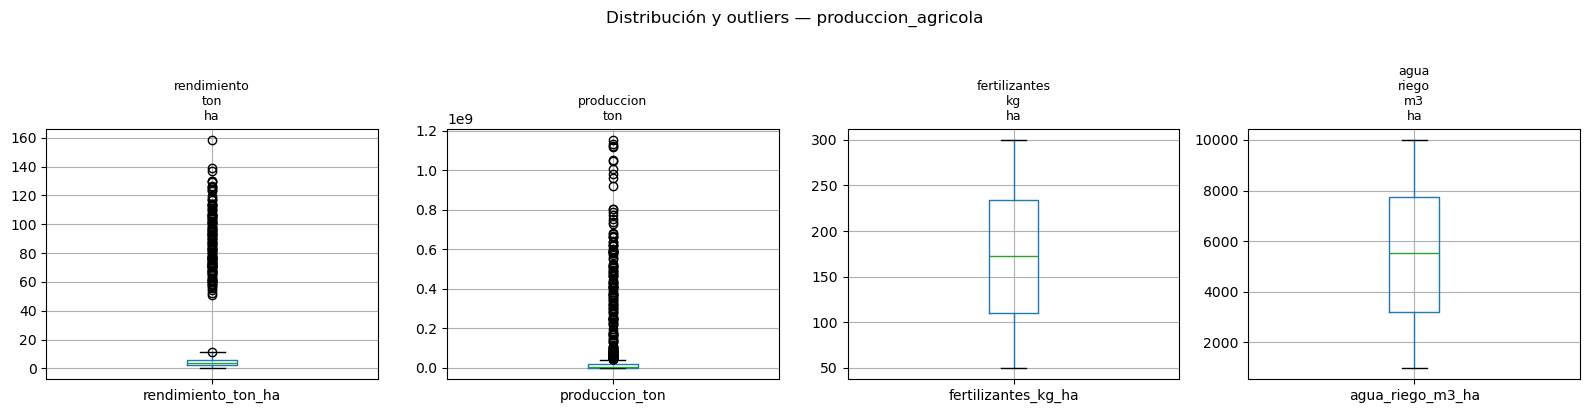

✅ Figura guardada en figures/


In [15]:
cols_outlier = ['rendimiento_ton_ha', 'produccion_ton',
                'fertilizantes_kg_ha', 'agua_riego_m3_ha']

print("📊 ANÁLISIS DE OUTLIERS — Método IQR")
print("=" * 55)

outliers_resumen = {}

for col in cols_outlier:
    Q1  = df_agr[col].quantile(0.25)
    Q3  = df_agr[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    mask_out = (df_agr[col] < lim_inf) | (df_agr[col] > lim_sup)
    n_out = mask_out.sum()
    outliers_resumen[col] = n_out
    print(f"\n  {col}")
    print(f"    Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f}")
    print(f"    Límites: [{lim_inf:.2f}, {lim_sup:.2f}]")
    print(f"    Outliers detectados: {n_out} ({n_out/len(df_agr)*100:.1f}%)")
    if n_out > 0:
        print(f"    Top 3 valores extremos:")
        print(df_agr[mask_out][['pais','cultivo','anio',col]]
              .nlargest(3, col).to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cols_outlier):
    df_agr.boxplot(column=col, ax=ax)
    ax.set_title(col.replace('_', '\n'), fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Distribución y outliers — produccion_agricola', y=1.02)
plt.tight_layout()
plt.savefig('../../documentacion/figures/05_outliers_produccion_agricola.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada en figures/")

Los outliers de rendimiento_ton_ha (131, 10.9%) y produccion_ton (160, 13.3%) son 100% atribuibles a Caña de azúcar, que tiene rendimientos biológicamente normales de 60–160 ton/ha frente a 2–8 ton/ha del resto de cultivos. No son errores — son outliers de dominio. El método IQR no es adecuado aquí porque mezcla cultivos con escalas radicalmente distintas.

#### Celda 4 - Validación de consistencia interna

In [16]:
# produccion_ton ≈ superficie_hectareas × rendimiento_ton_ha
df_agr['_produccion_calc'] = (df_agr['superficie_hectareas']
                               * df_agr['rendimiento_ton_ha'])

df_agr['_error_relativo'] = (
    (df_agr['produccion_ton'] - df_agr['_produccion_calc']).abs()
    / df_agr['_produccion_calc'].replace(0, np.nan)
)

umbral = 0.05  # 5%
mask_error = df_agr['_error_relativo'] > umbral
n_errores   = mask_error.sum()
n_ok        = (~mask_error).sum()

print(f"📐 Validación: produccion_ton ≈ superficie × rendimiento (umbral {umbral*100:.0f}%)")
print(f"\n   ✅ Registros que cumplen la identidad : {n_ok} ({n_ok/len(df_agr)*100:.1f}%)")
print(f"   ⚠️  Registros con error > {umbral*100:.0f}%          : {n_errores} ({n_errores/len(df_agr)*100:.1f}%)")

if n_errores > 0:
    print(f"\n   Muestra de registros con mayor desviación:")
    display(df_agr[mask_error][['pais','cultivo','anio','superficie_hectareas',
                                 'rendimiento_ton_ha','produccion_ton',
                                 '_produccion_calc','_error_relativo']]
            .nlargest(10, '_error_relativo').round(2))
else:
    print(f"\n   ✅ Todos los registros pasan la validación contable.")

# Eliminar columnas auxiliares
df_agr = df_agr.drop(columns=['_produccion_calc', '_error_relativo'])
print(f"\n✅ Columnas auxiliares de validación eliminadas")
print(f"📐 Dimensiones finales df_agr: {df_agr.shape}")

📐 Validación: produccion_ton ≈ superficie × rendimiento (umbral 5%)

   ✅ Registros que cumplen la identidad : 1200 (100.0%)
   ⚠️  Registros con error > 5%          : 0 (0.0%)

   ✅ Todos los registros pasan la validación contable.

✅ Columnas auxiliares de validación eliminadas
📐 Dimensiones finales df_agr: (1200, 11)


#### Celda 5 - Exportación

In [17]:
import os


archivo_agr = '../../data/processed/produccion_agricola_processed.csv'
df_agr.to_csv(archivo_agr, index=False, encoding='utf-8-sig')

print(f"✅ Exportación completada:")
print(f"   produccion_agricola_processed.csv — "
      f"{df_agr.shape[0]} filas × {df_agr.shape[1]} cols — "
      f"{os.path.getsize(archivo_agr)/1024:.1f} KB")

✅ Exportación completada:
   produccion_agricola_processed.csv — 1200 filas × 11 cols — 101.1 KB


### 3.2. produccion_ganadera.csv

### Bloque F — produccion_ganadera.csv

**Estructura del dataset:**
- **Granularidad:** un registro por combinación `pais × tipo_ganado × año`
- **9 columnas:** 3 identificadores + 6 métricas productivas/ambientales

**Tipos de ganado presentes:** bovino, porcino, avícola, ovino, caprino

**Problemáticas detectadas en exploración previa:**

| Problema | Columna | Naturaleza | Tratamiento |
|---|---|---|---|
| Ceros en lácteos | `produccion_leche_lt` | Estructural | `0 → NaN` en no-lácteos |
| Valores extremos | `intensidad_emisiones` | Posible error / caso real | Análisis IQR + decisión |
| Valores > 1.0 | `eficiencia_carne` | Físicamente imposible | Investigar y flagear |

**Nota `produccion_leche_lt`:**
Solo bovino, ovino y caprino producen leche de forma relevante.
El valor `0` en porcino y avícola **no significa "dato ausente"** sino
"no aplica biológicamente". Convertirlo a `NaN` refleja correctamente
la realidad y evita que estos ceros distorsionen estadísticas y modelos.

**Clave compuesta:** `pais + tipo_ganado + anio`

#### Celda 1 - Carga de datos y exploración inicial

In [18]:
df_gan = pd.read_csv('../../data/raw/structured/produccion_ganadera.csv')

print(f"✅ produccion_ganadera.csv cargado correctamente")
print(f"📐 Dimensiones: {df_gan.shape}")
print(f"\n📋 Columnas detectadas automáticamente:")
print(list(df_gan.columns))
print(f"\n📋 Tipos:")
print(df_gan.dtypes)
print(f"\n🔍 Primeras 4 filas:")
display(df_gan.head(4))

print(f"\n{'='*50}")
print(f"  CARDINALIDAD DE VARIABLES CLAVE")
print(f"{'='*50}")

# Detectar automáticamente la columna de país, ganado y año
col_pais    = df_gan.columns[0]
col_anio    = df_gan.columns[1]
col_ganado  = df_gan.columns[2]

print(f"  Países únicos   : {df_gan[col_pais].nunique()} → {sorted(df_gan[col_pais].unique())}")
print(f"  Tipos de ganado : {df_gan[col_ganado].nunique()} → {sorted(df_gan[col_ganado].unique())}")
print(f"  Rango temporal  : {df_gan[col_anio].min()} → {df_gan[col_anio].max()}")
print(f"\n  Registros por tipo de ganado:")
print(df_gan[col_ganado].value_counts().to_string())
print(f"\n  Registros por país:")
print(df_gan.groupby(col_pais).size().to_string())

print(f"\n📊 Estadísticas descriptivas:")
display(df_gan.describe().round(3))

✅ produccion_ganadera.csv cargado correctamente
📐 Dimensiones: (600, 9)

📋 Columnas detectadas automáticamente:
['pais', 'anio', 'tipo_ganado', 'cabezas_ganado', 'produccion_carne_ton', 'produccion_leche_lt', 'emisiones_ch4_ton_co2eq', 'intensidad_emisiones', 'eficiencia_carne']

📋 Tipos:
pais                           str
anio                         int64
tipo_ganado                    str
cabezas_ganado               int64
produccion_carne_ton         int64
produccion_leche_lt          int64
emisiones_ch4_ton_co2eq      int64
intensidad_emisiones       float64
eficiencia_carne           float64
dtype: object

🔍 Primeras 4 filas:


,pais,anio,tipo_ganado,cabezas_ganado,produccion_carne_ton,produccion_leche_lt,emisiones_ch4_ton_co2eq,intensidad_emisiones,eficiencia_carne
0,Argentina,2011,bovino,18160590,1857394,2355425160,1121740,0.062,0.1023
1,Argentina,2011,porcino,13481224,1528896,0,1984357,0.147,0.1134
2,Argentina,2011,avicola,979196737,1290153,0,10160819,0.010,0.0013
3,Argentina,2011,ovino,13789178,477282,329191349,5061273,0.367,0.0346



  CARDINALIDAD DE VARIABLES CLAVE
  Países únicos   : 12 → ['Alemania', 'Argentina', 'Australia', 'Brasil', 'China', 'España', 'Estados Unidos', 'Francia', 'India', 'Kenia', 'México', 'Nueva Zelanda']
  Tipos de ganado : 5 → ['avicola', 'bovino', 'caprino', 'ovino', 'porcino']
  Rango temporal  : 2011 → 2020

  Registros por tipo de ganado:
tipo_ganado
bovino     120
porcino    120
avicola    120
ovino      120
caprino    120

  Registros por país:
pais
Alemania          50
Argentina         50
Australia         50
Brasil            50
China             50
España            50
Estados Unidos    50
Francia           50
India             50
Kenia             50
México            50
Nueva Zelanda     50

📊 Estadísticas descriptivas:


,anio,cabezas_ganado,produccion_carne_ton,produccion_leche_lt,emisiones_ch4_ton_co2eq,intensidad_emisiones,eficiencia_carne
count,600.000,6.000000e+02,600.000,6.000000e+02,6.000000e+02,600.000,600.000
mean,2015.500,1.304835e+08,1227859.670,1.163095e+09,1.254746e+07,1.232,0.133
std,2.875,2.774810e+08,1272357.071,2.487433e+09,1.195771e+07,2.711,0.307
min,2011.000,2.601110e+05,7534.000,0.000000e+00,1.550720e+05,0.002,0.000
25%,2013.000,8.172389e+06,286101.250,0.000000e+00,4.321418e+06,0.125,0.009
50%,2015.500,1.550925e+07,636018.500,1.100148e+08,8.717192e+06,0.506,0.035
75%,2018.000,3.978414e+07,1903156.000,4.546381e+08,1.599721e+07,1.033,0.133
max,2020.000,1.383812e+09,6536095.000,1.166286e+10,6.136727e+07,31.303,2.917


#### Celda 2 - Gestión nulos y duplicados

In [19]:
print(f"{'='*50}")
print(f"  NULOS")
print(f"{'='*50}")
nulos = df_gan.isnull().sum()
nulos_pct = (nulos / len(df_gan) * 100).round(2)
resumen_nulos = pd.DataFrame({'n_nulos': nulos, 'pct': nulos_pct})
if resumen_nulos['n_nulos'].sum() > 0:
    print(resumen_nulos[resumen_nulos['n_nulos'] > 0].to_string())
else:
    print("  ✅ Sin nulos detectados en carga")

print(f"\n{'='*50}")
print(f"  DUPLICADOS")
print(f"{'='*50}")
n_dup = df_gan.duplicated().sum()
n_dup_clave = df_gan.duplicated(subset=['pais','tipo_ganado','anio']).sum()
print(f"  Filas duplicadas totales              : {n_dup}")
print(f"  Duplicados en clave pais+tipo+anio    : {n_dup_clave}")

print(f"\n{'='*50}")
print(f"  DISTRIBUCIÓN produccion_leche_lt = 0")
print(f"{'='*50}")
ceros_leche = df_gan.groupby('tipo_ganado')['produccion_leche_lt'].apply(
    lambda x: (x == 0).sum()
)
total_leche = df_gan.groupby('tipo_ganado')['produccion_leche_lt'].count()
print(pd.DataFrame({'ceros': ceros_leche,
                    'total': total_leche,
                    'pct_ceros': (ceros_leche/total_leche*100).round(1)}).to_string())

  NULOS
  ✅ Sin nulos detectados en carga

  DUPLICADOS
  Filas duplicadas totales              : 0
  Duplicados en clave pais+tipo+anio    : 0

  DISTRIBUCIÓN produccion_leche_lt = 0
             ceros  total  pct_ceros
tipo_ganado                         
avicola        120    120      100.0
bovino           0    120        0.0
caprino          0    120        0.0
ovino            0    120        0.0
porcino        120    120      100.0


#### Celda 3 - Limpieza tipos y datos estructurales

In [22]:
# Tipos básicos — usando pd.to_numeric por robustez
df_gan['anio'] = pd.to_numeric(df_gan['anio'], errors='coerce').astype('Int64')
for col in ['cabezas_ganado','produccion_carne_ton','produccion_leche_lt']:
    df_gan[col] = pd.to_numeric(df_gan[col], errors='coerce')
for col in ['intensidad_emisiones','eficiencia_carne']:
    df_gan[col] = pd.to_numeric(df_gan[col], errors='coerce')
for col in df_gan.select_dtypes('object').columns:
    df_gan[col] = df_gan[col].str.strip()

# Ceros estructurales en produccion_leche_lt
# Porcino y avícola no producen leche → 0 significa "no aplica", no "dato ausente"
TIPOS_NO_LACTEOS = ['porcino', 'avicola']
mask_no_lacteo = df_gan['tipo_ganado'].isin(TIPOS_NO_LACTEOS)
n_ceros_convertidos = (df_gan.loc[mask_no_lacteo, 'produccion_leche_lt'] == 0).sum()
df_gan.loc[mask_no_lacteo, 'produccion_leche_lt'] = np.where(
    df_gan.loc[mask_no_lacteo, 'produccion_leche_lt'] == 0,
    np.nan,
    df_gan.loc[mask_no_lacteo, 'produccion_leche_lt']
)

print("✅ Tipos convertidos correctamente")
print(f"   Ceros → NaN en produccion_leche_lt (porcino/avícola): {n_ceros_convertidos} registros")
print(f"\n📋 Tipos finales:")
print(df_gan.dtypes)
print(f"\n🕳️  Nulos post-limpieza (NaN estructurales esperados en leche):")
print(df_gan.isnull().sum().to_string())

✅ Tipos convertidos correctamente
   Ceros → NaN en produccion_leche_lt (porcino/avícola): 240 registros

📋 Tipos finales:
pais                           str
anio                         Int64
tipo_ganado                    str
cabezas_ganado               int64
produccion_carne_ton         int64
produccion_leche_lt        float64
emisiones_ch4_ton_co2eq      int64
intensidad_emisiones       float64
eficiencia_carne           float64
dtype: object

🕳️  Nulos post-limpieza (NaN estructurales esperados en leche):
pais                         0
anio                         0
tipo_ganado                  0
cabezas_ganado               0
produccion_carne_ton         0
produccion_leche_lt        240
emisiones_ch4_ton_co2eq      0
intensidad_emisiones         0
eficiencia_carne             0


C:\Users\david\AppData\Local\Temp\ipykernel_10328\1931214797.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_gan.select_dtypes('object').columns:


#### Celda 4 - Detección y análisis de outliers críticos

In [23]:
print("📊 ANÁLISIS DE OUTLIERS CRÍTICOS")
print("=" * 55)

# ── 1. intensidad_emisiones ────────────────────────────────
col = 'intensidad_emisiones'
Q1, Q3 = df_gan[col].quantile([0.25, 0.75])
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
mask_em = df_gan[col] > lim_sup

print(f"\n  {col}")
print(f"    Q1={Q1:.4f} | Q3={Q3:.4f} | IQR={IQR:.4f} | Límite sup={lim_sup:.4f}")
print(f"    Outliers detectados: {mask_em.sum()} ({mask_em.mean()*100:.1f}%)")
if mask_em.sum() > 0:
    print(f"    Detalle (top 10):")
    print(df_gan[mask_em][['pais','tipo_ganado','anio', col]]
          .sort_values(col, ascending=False).head(10).to_string(index=False))

# ── 2. eficiencia_carne ────────────────────────────────────
col2 = 'eficiencia_carne'
mask_ef = df_gan[col2] > 1.0

print(f"\n  {col2}")
print(f"    Rango válido biológico: [0.0, 1.0]")
print(f"    Valores > 1.0 (físicamente imposibles): {mask_ef.sum()} ({mask_ef.mean()*100:.1f}%)")
if mask_ef.sum() > 0:
    print(f"    Detalle:")
    print(df_gan[mask_ef][['pais','tipo_ganado','anio', col2]]
          .sort_values(col2, ascending=False).to_string(index=False))

# ── 3. emisiones_ch4_ton_co2eq (columna adicional detectada) ──
col3 = 'emisiones_ch4_ton_co2eq'
Q1e, Q3e = df_gan[col3].quantile([0.25, 0.75])
IQRe = Q3e - Q1e
lim_supe = Q3e + 1.5 * IQRe
mask_ch4 = df_gan[col3] > lim_supe

print(f"\n  {col3}")
print(f"    Q1={Q1e:,.0f} | Q3={Q3e:,.0f} | IQR={IQRe:,.0f} | Límite sup={lim_supe:,.0f}")
print(f"    Outliers detectados: {mask_ch4.sum()} ({mask_ch4.mean()*100:.1f}%)")

# ── Decisión y aplicación ──────────────────────────────────
print(f"\n{'='*55}")
print("  DECISIÓN DE TRATAMIENTO:")
print(f"{'='*55}")
print("""
  intensidad_emisiones outliers:
  → MANTENER + flag 'flag_emision_extrema'
    Valores reales en ganadería extensiva ineficiente.
    Eliminarlos introduciría sesgo optimista en el modelo.

  eficiencia_carne > 1.0:
  → WINSORIZAR a 1.0 + flag 'flag_eficiencia_anomala'
    Un ratio > 1.0 viola la conservación de masa.
    Probable error de entrada. Se capea al máximo físico.

  emisiones_ch4_ton_co2eq outliers:
  → MANTENER (proporcionales al tamaño del rebaño).
    No se crean flags adicionales.
""")

# Aplicar decisiones
df_gan['flag_emision_extrema']   = mask_em.astype(int)
df_gan['flag_eficiencia_anomala'] = mask_ef.astype(int)
df_gan['eficiencia_carne']        = df_gan['eficiencia_carne'].clip(upper=1.0)

# Corrección del warning de pandas sobre select_dtypes
for col in df_gan.select_dtypes(include='str').columns:
    df_gan[col] = df_gan[col].str.strip()

print(f"  ✅ flag_emision_extrema     : {df_gan['flag_emision_extrema'].sum()} registros flaggeados")
print(f"  ✅ flag_eficiencia_anomala  : {df_gan['flag_eficiencia_anomala'].sum()} registros flaggeados")
print(f"  ✅ eficiencia_carne winsorizad a máx 1.0")

📊 ANÁLISIS DE OUTLIERS CRÍTICOS

  intensidad_emisiones
    Q1=0.1247 | Q3=1.0333 | IQR=0.9085 | Límite sup=2.3960
    Outliers detectados: 67 (11.2%)
    Detalle (top 10):
         pais tipo_ganado  anio  intensidad_emisiones
        Kenia       ovino  2016                31.303
Nueva Zelanda     caprino  2018                20.535
     Alemania     porcino  2011                20.075
       Brasil     caprino  2013                17.381
     Alemania      bovino  2019                16.087
       España     caprino  2019                15.948
      Francia     porcino  2016                15.393
       España      bovino  2017                13.715
     Alemania     caprino  2012                13.012
    Argentina     caprino  2020                12.869

  eficiencia_carne
    Rango válido biológico: [0.0, 1.0]
    Valores > 1.0 (físicamente imposibles): 13 (2.2%)
    Detalle:
          pais tipo_ganado  anio  eficiencia_carne
      Alemania     porcino  2011            2.9170
Estad

#### Celda 5 - Ingeniería de características básica

Creamos dos nuevas características `carne_kg_por_cabeza` y `leche_lt_por_cabeza`. Cómo sus nombres indican se divide la cantidad total de producto entre las cabezas de ganado, estas **métricas** se utilizarán principalmente de cara a medir la **productividad de las explotaciones ganaderas**.

In [ ]:
# Feature 1: carne producida por cabeza (kg/cabeza)
df_gan['carne_kg_por_cabeza'] = np.where(
    df_gan['cabezas_ganado'] > 0,
    (df_gan['produccion_carne_ton'] * 1000) / df_gan['cabezas_ganado'],
    np.nan
)

# Feature 2: leche por cabeza (litros/cabeza) — solo tipos lácteos
TIPOS_LACTEOS = ['bovino', 'ovino', 'caprino']
mask_lacteo = df_gan['tipo_ganado'].isin(TIPOS_LACTEOS)

df_gan['leche_lt_por_cabeza'] = np.where(
    mask_lacteo & (df_gan['cabezas_ganado'] > 0),
    df_gan['produccion_leche_lt'] / df_gan['cabezas_ganado'],
    np.nan
)

print("✅ Features de eficiencia productiva creadas")
print(f"\n  carne_kg_por_cabeza — estadísticas por tipo de ganado:")
print(df_gan.groupby('tipo_ganado')['carne_kg_por_cabeza']
      .agg(['mean','min','max']).round(3).to_string())

print(f"\n  leche_lt_por_cabeza — estadísticas (solo tipos lácteos):")
print(df_gan[mask_lacteo].groupby('tipo_ganado')['leche_lt_por_cabeza']
      .agg(['mean','min','max']).round(3).to_string())

print(f"\n📐 Dimensiones finales df_gan : {df_gan.shape}")
print(f"📋 Columnas finales ({len(df_gan.columns)}):")
for i, col in enumerate(df_gan.columns, 1):
    print(f"   {i:02d}. {col}")

#### Celda 6 - Exportación

In [25]:
archivo_gan = '../../data/processed/produccion_ganadera_processed.csv'
df_gan.to_csv(archivo_gan, index=False, encoding='utf-8-sig')

print(f"✅ Exportación completada:")
print(f"   produccion_ganadera_processed.csv — "
      f"{df_gan.shape[0]} filas × {df_gan.shape[1]} cols — "
      f"{os.path.getsize(archivo_gan)/1024:.1f} KB")

✅ Exportación completada:
   produccion_ganadera_processed.csv — 600 filas × 11 cols — 42.0 KB


### 3.3. precios_mercado.csv

**Estructura del dataset:**
- **Granularidad:** un registro por combinación `fecha × pais × producto`
- **9 columnas:** 1 temporal + 2 identificadores + 6 métricas de precio/mercado

**Características temporales del dataset:**
Las fechas **no son periódicas uniformes**: el primer registro de cada período
es el día 1 del mes, y el segundo es el día 15. Esto genera una frecuencia
**bimensual irregular** (no es mensual estricta ni quincenal uniforme).
Esta irregularidad debe documentarse y tenerse en cuenta en Series Temporales
(Fase 3 del proyecto).

**Validación interna clave:**
`precio_min_mes ≤ precio_usd_ton ≤ precio_max_mes`
Toda violación de esta relación indica un error de entrada.

#### Celda 1 - Carga y exploración inicial

In [26]:
df_pre = pd.read_csv('../../data/raw/structured/precios_mercado.csv')

print(f"✅ precios_mercado.csv cargado correctamente")
print(f"📐 Dimensiones: {df_pre.shape}")
print(f"\n📋 Columnas y tipos:")
print(df_pre.dtypes)
print(f"\n🔍 Primeras 3 filas:")
display(df_pre.head(3))

print(f"\n{'='*52}")
print(f"  CARDINALIDAD DE VARIABLES CLAVE")
print(f"{'='*52}")
print(f"  Países únicos   : {df_pre['pais'].nunique()} → {sorted(df_pre['pais'].unique())}")
print(f"  Productos únicos: {df_pre['producto'].nunique()} → {sorted(df_pre['producto'].unique())}")
print(f"  Mercados únicos : {df_pre['mercado_principal'].nunique()} → {sorted(df_pre['mercado_principal'].unique())}")
print(f"  Tendencias únicas: {df_pre['tendencia_30_dias'].unique()}")

print(f"\n  Fechas únicas   : {df_pre['fecha'].nunique()}")
print(f"  Rango de fechas : {df_pre['fecha'].min()} → {df_pre['fecha'].max()}")
print(f"  Registros/fecha (media): {len(df_pre) / df_pre['fecha'].nunique():.1f}")

print(f"\n📊 Distribución de registros por producto:")
print(df_pre['producto'].value_counts().to_string())

print(f"\n📊 Estadísticas descriptivas:")
display(df_pre.describe().round(3))

✅ precios_mercado.csv cargado correctamente
📐 Dimensiones: (864, 9)

📋 Columnas y tipos:
fecha                      str
pais                       str
producto                   str
precio_usd_ton         float64
volumen_operado_ton      int64
tendencia_30_dias          str
mercado_principal          str
precio_min_mes         float64
precio_max_mes         float64
dtype: object

🔍 Primeras 3 filas:


,fecha,pais,producto,precio_usd_ton,volumen_operado_ton,tendencia_30_dias,mercado_principal,precio_min_mes,precio_max_mes
0,2021-01-01,Argentina,Carne_bovina,4299.14,127922,subiendo,UE,3844.74,4517.42
1,2021-01-01,Argentina,Arroz,330.04,73231,subiendo,Sudeste Asiático,310.10,359.86
2,2021-01-01,Argentina,Maíz,210.36,11666,bajando,Japón,200.56,238.83



  CARDINALIDAD DE VARIABLES CLAVE
  Países únicos   : 12 → ['Alemania', 'Argentina', 'Australia', 'Brasil', 'China', 'España', 'Estados Unidos', 'Francia', 'India', 'Kenia', 'México', 'Nueva Zelanda']
  Productos únicos: 7 → ['Arroz', 'Carne_bovina', 'Carne_porcina', 'Leche', 'Maíz', 'Soja', 'Trigo']
  Mercados únicos : 8 → ['China', 'Estados Unidos', 'Japón', 'México', 'Oriente Medio', 'Sudeste Asiático', 'UE', 'África']
  Tendencias únicas: <ArrowStringArray>
['subiendo', 'bajando', 'estable']
Length: 3, dtype: str

  Fechas únicas   : 24
  Rango de fechas : 2021-01-01 → 2022-12-15
  Registros/fecha (media): 36.0

📊 Distribución de registros por producto:
producto
Maíz             136
Carne_porcina    135
Soja             130
Leche            117
Carne_bovina     116
Trigo            116
Arroz            114

📊 Estadísticas descriptivas:


,precio_usd_ton,volumen_operado_ton,precio_min_mes,precio_max_mes
count,864.000,864.000,864.000,864.000
mean,1186.331,99648.072,1086.146,1287.029
std,1394.776,119798.419,1280.572,1516.878
min,155.450,1079.000,134.150,171.590
25%,312.772,23293.250,283.565,335.008
50%,377.595,43731.000,350.135,409.470
75%,2363.350,127231.500,2157.228,2552.930
max,4887.620,498724.000,4574.160,5378.760


#### Celda 2 - Limpieza de tipos

In [27]:
# fecha → datetime
df_pre['fecha'] = pd.to_datetime(df_pre['fecha'], errors='coerce')

# Extraer componentes temporales útiles para ML y EDA
df_pre['anio'] = df_pre['fecha'].dt.year
df_pre['mes']  = df_pre['fecha'].dt.month

# tendencia_30_dias → ordinal numérico
mapa_tendencia = {'bajando': -1, 'estable': 0, 'subiendo': 1}
df_pre['tendencia_30_dias_num'] = df_pre['tendencia_30_dias'].map(mapa_tendencia)

# Verificar que el mapeo es completo (no hay valores no mapeados)
n_no_mapeados = df_pre['tendencia_30_dias_num'].isnull().sum()

# Numéricos → float por robustez
for col in ['precio_usd_ton', 'precio_min_mes', 'precio_max_mes']:
    df_pre[col] = pd.to_numeric(df_pre[col], errors='coerce')
df_pre['volumen_operado_ton'] = pd.to_numeric(df_pre['volumen_operado_ton'],
                                               errors='coerce')

# Strings → strip
for col in df_pre.select_dtypes(include='str').columns:
    df_pre[col] = df_pre[col].str.strip()

print("✅ Limpieza de tipos completada")
print(f"\n📋 Tipos finales:")
print(df_pre.dtypes)
print(f"\n  Valores de tendencia_30_dias_num: "
      f"{sorted(df_pre['tendencia_30_dias_num'].dropna().unique())}")
print(f"  Valores no mapeados en tendencia: {n_no_mapeados}")
print(f"\n  Rango temporal tras conversión: "
      f"{df_pre['fecha'].min().date()} → {df_pre['fecha'].max().date()}")

✅ Limpieza de tipos completada

📋 Tipos finales:
fecha                    datetime64[us]
pais                                str
producto                            str
precio_usd_ton                  float64
volumen_operado_ton               int64
tendencia_30_dias                   str
mercado_principal                   str
precio_min_mes                  float64
precio_max_mes                  float64
anio                              int32
mes                               int32
tendencia_30_dias_num             int64
dtype: object

  Valores de tendencia_30_dias_num: [np.int64(-1), np.int64(0), np.int64(1)]
  Valores no mapeados en tendencia: 0

  Rango temporal tras conversión: 2021-01-01 → 2022-12-15


#### Celda 3 - Nulos, duplicados y gaps temporales

In [28]:
print(f"{'='*52}")
print(f"  NULOS")
print(f"{'='*52}")
nulos = df_pre.isnull().sum()
if nulos.sum() > 0:
    print(nulos[nulos > 0].to_string())
else:
    print("  ✅ Sin nulos detectados")

print(f"\n{'='*52}")
print(f"  DUPLICADOS")
print(f"{'='*52}")
n_dup = df_pre.duplicated().sum()
n_dup_clave = df_pre.duplicated(subset=['fecha','pais','producto']).sum()
print(f"  Filas duplicadas totales            : {n_dup}")
print(f"  Duplicados en clave fecha+pais+prod : {n_dup_clave}")

print(f"\n{'='*52}")
print(f"  ANÁLISIS DE REGULARIDAD TEMPORAL")
print(f"{'='*52}")
fechas_unicas = pd.to_datetime(df_pre['fecha'].unique())
fechas_sorted = sorted(fechas_unicas)
diffs = pd.Series(fechas_sorted).diff().dropna().dt.days
print(f"  Fechas únicas       : {len(fechas_sorted)}")
print(f"  Diferencia entre fechas (días):")
print(f"    min={diffs.min()} | max={diffs.max()} | "
      f"media={diffs.mean():.1f} | moda={diffs.mode()[0]}")
print(f"\n  Distribución de intervalos:")
print(diffs.value_counts().sort_index().to_string())

print(f"\n{'='*52}")
print(f"  COBERTURA pais × producto")
print(f"{'='*52}")
cobertura = df_pre.groupby(['pais','producto'])['fecha'].count()
print(f"  Registros por combinación pais+producto:")
print(f"    min={cobertura.min()} | max={cobertura.max()} | "
      f"media={cobertura.mean():.1f}")
combinaciones_incompletas = cobertura[cobertura < cobertura.max()]
if len(combinaciones_incompletas) > 0:
    print(f"\n  ⚠️ Combinaciones con menos registros que el máximo:")
    print(combinaciones_incompletas.to_string())
else:
    print(f"\n  ✅ Todas las combinaciones tienen el mismo número de registros")

  NULOS
  ✅ Sin nulos detectados

  DUPLICADOS
  Filas duplicadas totales            : 0
  Duplicados en clave fecha+pais+prod : 0

  ANÁLISIS DE REGULARIDAD TEMPORAL
  Fechas únicas       : 24
  Diferencia entre fechas (días):
    min=28 | max=45 | media=31.0 | moda=31

  Distribución de intervalos:
28     2
30     8
31    12
45     1

  COBERTURA pais × producto
  Registros por combinación pais+producto:
    min=6 | max=20 | media=10.3

  ⚠️ Combinaciones con menos registros que el máximo:
pais            producto     
Alemania        Arroz             8
                Carne_bovina     10
                Carne_porcina    12
                Leche             9
                Maíz             12
                Soja             13
                Trigo             8
Argentina       Arroz            10
                Carne_bovina     12
                Carne_porcina    11
                Leche            13
                Maíz              9
                Soja              7
     

La serie es pseudo-mensual irregular: 24 fechas únicas, intervalos de 28–45 días (moda 31). El gap de 45 días es un salto puntual, no un patrón. Esto es relevante para la Fase de Series Temporales.

La exploración de cobertura revela que el dataset de precios es un
**panel desbalanceado**: ninguna combinación `pais × producto` tiene
registros en todos los períodos disponibles. El rango varía entre
6 y 20 registros sobre 24 períodos posibles.

**Casos extremos detectados:**
- `Estados Unidos × Arroz`: 6 registros (25% de cobertura)
- `Francia × Trigo`: 6 registros
- `Nueva Zelanda × Leche`: 6 registros
- `Nueva Zelanda`: no tiene datos de `Maíz` en ningún período

**Causas probables:** rotación de productos reportados por país en
distintos períodos — no necesariamente datos perdidos, sino que no
todos los países negocian todos los productos en todos los meses.

**Implicaciones para fases posteriores:**
- **EDA (Fase 2):** analizar precios por producto, no por país×producto
- **Series Temporales (Fase 3):** aplicar interpolación o modelos que
  toleren series irregulares (ej. Prophet, ARIMA con gaps)
- **ML supervisado:** no asumir panel balanceado al hacer pivots o lags

#### Celda 4 - Validación de rangos

In [29]:
print(f"{'='*52}")
print(f"  VALIDACIÓN: precio_min ≤ precio_usd_ton ≤ precio_max")
print(f"{'='*52}")

# Violación inferior: precio_usd_ton < precio_min_mes
mask_bajo_min = df_pre['precio_usd_ton'] < df_pre['precio_min_mes']

# Violación superior: precio_usd_ton > precio_max_mes
mask_sobre_max = df_pre['precio_usd_ton'] > df_pre['precio_max_mes']

mask_cualquier = mask_bajo_min | mask_sobre_max

print(f"\n  precio_usd_ton < precio_min_mes : {mask_bajo_min.sum()} registros")
print(f"  precio_usd_ton > precio_max_mes : {mask_sobre_max.sum()} registros")
print(f"  Total violaciones               : {mask_cualquier.sum()} "
      f"({mask_cualquier.mean()*100:.1f}%)")

if mask_cualquier.sum() > 0:
    print(f"\n  Detalle de violaciones:")
    display(df_pre[mask_cualquier][['fecha','pais','producto','precio_usd_ton',
                                    'precio_min_mes','precio_max_mes']].head(15))

# Flagear violaciones
df_pre['flag_precio_fuera_rango'] = mask_cualquier.astype(int)

print(f"\n  ✅ flag_precio_fuera_rango creado: "
      f"{df_pre['flag_precio_fuera_rango'].sum()} registros flaggeados")

  VALIDACIÓN: precio_min ≤ precio_usd_ton ≤ precio_max

  precio_usd_ton < precio_min_mes : 0 registros
  precio_usd_ton > precio_max_mes : 0 registros
  Total violaciones               : 0 (0.0%)

  ✅ flag_precio_fuera_rango creado: 0 registros flaggeados


#### Celda 5 - Ingeniería de características básicas

In [30]:
# Feature 1: spread absoluto (amplitud del rango de precio en el período)
df_pre['spread_precio'] = df_pre['precio_max_mes'] - df_pre['precio_min_mes']

# Feature 2: spread relativo (volatilidad como % del precio spot)
df_pre['spread_pct'] = np.where(
    df_pre['precio_usd_ton'] > 0,
    df_pre['spread_precio'] / df_pre['precio_usd_ton'],
    np.nan
)

print("✅ Features de volatilidad de precio creadas")
print(f"\n  spread_precio — estadísticas generales:")
print(df_pre['spread_precio'].describe().round(2).to_string())

print(f"\n  spread_pct (ratio) — estadísticas generales:")
print(df_pre['spread_pct'].describe().round(4).to_string())

print(f"\n  Productos con mayor volatilidad relativa media (spread_pct):")
print(df_pre.groupby('producto')['spread_pct']
      .mean().sort_values(ascending=False).round(4).to_string())

print(f"\n📐 Dimensiones finales df_pre : {df_pre.shape}")
print(f"📋 Columnas finales ({len(df_pre.columns)}):")
for i, col in enumerate(df_pre.columns, 1):
    print(f"   {i:02d}. {col}")

✅ Features de volatilidad de precio creadas

  spread_precio — estadísticas generales:
count     864.00
mean      200.88
std       254.30
min        10.65
25%        42.50
50%        68.87
75%       313.33
max      1139.32

  spread_pct (ratio) — estadísticas generales:
count    864.0000
mean       0.1685
std        0.0518
min        0.0417
25%        0.1324
50%        0.1687
75%        0.2054
max        0.2902

  Productos con mayor volatilidad relativa media (spread_pct):
producto
Arroz            0.1735
Leche            0.1727
Carne_bovina     0.1701
Carne_porcina    0.1689
Maíz             0.1684
Soja             0.1659
Trigo            0.1603

📐 Dimensiones finales df_pre : (864, 15)
📋 Columnas finales (15):
   01. fecha
   02. pais
   03. producto
   04. precio_usd_ton
   05. volumen_operado_ton
   06. tendencia_30_dias
   07. mercado_principal
   08. precio_min_mes
   09. precio_max_mes
   10. anio
   11. mes
   12. tendencia_30_dias_num
   13. flag_precio_fuera_rango
   14. spr

#### Celda 6 - Exportación

In [31]:
archivo_pre = '../../data/processed/precios_mercado_processed.csv'
df_pre.to_csv(archivo_pre, index=False, encoding='utf-8-sig')

print(f"✅ Exportación completada:")
print(f"   precios_mercado_processed.csv — "
      f"{df_pre.shape[0]} filas × {df_pre.shape[1]} cols — "
      f"{os.path.getsize(archivo_pre)/1024:.1f} KB")

✅ Exportación completada:
   precios_mercado_processed.csv — 864 filas × 15 cols — 104.1 KB


### 3.4. imagenes_metadata.csv

**Estructura del dataset:**
- **Granularidad:** un registro por imagen satelital capturada
- **15 columnas:** identificación + localización + fecha + índices espectrales
  + metadatos técnicos de captura + variable target de uso del suelo

**Conexión con el enunciado — Problema 5 (Visión por Computador):**
La columna `uso_suelo_predominante` es la **variable target** del modelo
de clasificación de uso del suelo mediante imágenes satelitales.
Sus 6 clases son: `agricultura_intensiva`, `agricultura_extensiva`,
`ganaderia`, `bosque`, `urbano`, `mixto`.

En esta fase preparamos los metadatos. Las imágenes reales (arrays
de píxeles) se procesarían por separado con PyTorch/TensorFlow en Fase 3.

**Consideración técnica — NDVI vs EVI:**
- **NDVI** (Normalized Difference Vegetation Index): rango teórico [−1, 1].
  Valores > 1.0 son físicamente imposibles → se flageará `indice_ndvi_max > 1.0`
- **EVI** (Enhanced Vegetation Index): diseñado para corregir saturación del
  NDVI en vegetación muy densa. Puede superar 1.0 legítimamente → se mantiene

#### Celda 1 - Carga y exploración inicial

In [32]:
df_img = pd.read_csv('../../data/raw/structured/imagenes_metadata.csv')

print(f"✅ imagenes_metadata.csv cargado correctamente")
print(f"📐 Dimensiones: {df_img.shape}")
print(f"\n📋 Columnas y tipos:")
print(df_img.dtypes)
print(f"\n🔍 Primeras 3 filas:")
display(df_img.head(3))

print(f"\n{'='*52}")
print(f"  CARDINALIDAD DE VARIABLES CLAVE")
print(f"{'='*52}")
print(f"  Imágenes únicas    : {df_img['imagen_id'].nunique()}")
print(f"  Países únicos      : {df_img['pais'].nunique()} → {sorted(df_img['pais'].unique())}")
print(f"  Regiones únicas    : {df_img['region'].nunique()}")
print(f"  Satélites          : {df_img['satelite'].unique()}")
print(f"  Resoluciones (m)   : {sorted(df_img['resolucion_metros'].unique())}")
print(f"  Bandas disponibles : {df_img['bandas_disponibles'].unique()}")

print(f"\n  Rango temporal: {df_img['fecha'].min()} → {df_img['fecha'].max()}")

print(f"\n  Distribución por uso_suelo_predominante (variable target):")
print(df_img['uso_suelo_predominante'].value_counts().to_string())

print(f"\n  Distribución por calidad_imagen:")
print(df_img['calidad_imagen'].value_counts().to_string())

print(f"\n  Distribución por satélite:")
print(df_img['satelite'].value_counts().to_string())

print(f"\n📊 Estadísticas de índices espectrales:")
display(df_img[['indice_ndvi_promedio','indice_ndvi_min',
                'indice_ndvi_max','indice_evi',
                'humedad_suelo_estimada','cobertura_nubes']].describe().round(4))

✅ imagenes_metadata.csv cargado correctamente
📐 Dimensiones: (250, 15)

📋 Columnas y tipos:
imagen_id                     str
pais                          str
region                        str
fecha                         str
indice_ndvi_promedio      float64
indice_ndvi_min           float64
indice_ndvi_max           float64
indice_evi                float64
uso_suelo_predominante        str
humedad_suelo_estimada    float64
cobertura_nubes           float64
resolucion_metros           int64
satelite                      str
bandas_disponibles            str
calidad_imagen                str
dtype: object

🔍 Primeras 3 filas:


,imagen_id,pais,region,fecha,indice_ndvi_promedio,indice_ndvi_min,indice_ndvi_max,indice_evi,uso_suelo_predominante,humedad_suelo_estimada,cobertura_nubes,resolucion_metros,satelite,bandas_disponibles,calidad_imagen
0,SAT_FRA_202001_000,Francia,Región Principal,2020-01-15,0.391,0.259,0.432,0.432,bosque,0.378,0.074,30,MODIS,"RGB, NIR, SWIR",media
1,SAT_ARG_202001_001,Argentina,Noroeste,2020-01-31,0.488,0.390,0.601,0.555,mixto,0.480,0.055,30,Sentinel-2,"RGB, NIR, SWIR",baja
2,SAT_CHN_202003_002,China,Región Principal,2020-03-01,0.546,0.433,0.622,0.655,urbano,0.552,0.099,20,MODIS,"RGB, NIR, SWIR",baja



  CARDINALIDAD DE VARIABLES CLAVE
  Imágenes únicas    : 250
  Países únicos      : 8 → ['Alemania', 'Argentina', 'Australia', 'Brasil', 'China', 'Estados Unidos', 'Francia', 'India']
  Regiones únicas    : 21
  Satélites          : <ArrowStringArray>
['MODIS', 'Sentinel-2', 'Landsat 8']
Length: 3, dtype: str
  Resoluciones (m)   : [np.int64(10), np.int64(15), np.int64(20), np.int64(30), np.int64(60)]
  Bandas disponibles : <ArrowStringArray>
['RGB, NIR, SWIR']
Length: 1, dtype: str

  Rango temporal: 2020-01-15 → 2033-07-20

  Distribución por uso_suelo_predominante (variable target):
uso_suelo_predominante
bosque                   48
urbano                   47
agricultura_extensiva    46
ganaderia                39
agricultura_intensiva    36
mixto                    34

  Distribución por calidad_imagen:
calidad_imagen
baja     91
media    86
alta     73

  Distribución por satélite:
satelite
Sentinel-2    86
Landsat 8     86
MODIS         78

📊 Estadísticas de índices espectrales

,indice_ndvi_promedio,indice_ndvi_min,indice_ndvi_max,indice_evi,humedad_suelo_estimada,cobertura_nubes
count,250.0000,250.0000,250.0000,250.0000,250.0000,250.0000
mean,0.6542,0.4745,0.7541,0.7869,0.5810,0.1491
std,0.1658,0.1326,0.1988,0.2070,0.1844,0.0849
min,0.3010,0.2080,0.3360,0.3680,0.2030,0.0010
25%,0.5322,0.3792,0.6120,0.6382,0.4485,0.0788
50%,0.6610,0.4860,0.7675,0.7990,0.6140,0.1480
75%,0.7928,0.5665,0.9175,0.9428,0.7258,0.2198
max,0.9490,0.7850,1.1710,1.1670,0.8980,0.2990


#### Celda 2 - Limpieza de tipos

In [33]:
# fecha → datetime
df_img['fecha'] = pd.to_datetime(df_img['fecha'], errors='coerce')
df_img['anio']  = df_img['fecha'].dt.year
df_img['mes']   = df_img['fecha'].dt.month

# calidad_imagen → ordinal numérico (mantener columna original también)
mapa_calidad = {'baja': 1, 'media': 2, 'alta': 3}
df_img['calidad_imagen_num'] = df_img['calidad_imagen'].map(mapa_calidad)
n_no_mapeados = df_img['calidad_imagen_num'].isnull().sum()

# Índices espectrales y métricas → float
cols_float = ['indice_ndvi_promedio', 'indice_ndvi_min', 'indice_ndvi_max',
              'indice_evi', 'humedad_suelo_estimada', 'cobertura_nubes']
for col in cols_float:
    df_img[col] = pd.to_numeric(df_img[col], errors='coerce')

# resolucion_metros → int
df_img['resolucion_metros'] = pd.to_numeric(df_img['resolucion_metros'],
                                             errors='coerce').astype('Int64')

# Strings → strip
for col in df_img.select_dtypes(include='str').columns:
    df_img[col] = df_img[col].str.strip()

print("✅ Limpieza de tipos completada")
print(f"\n📋 Tipos finales:")
print(df_img.dtypes)
print(f"\n  Valores no mapeados en calidad_imagen: {n_no_mapeados}")
print(f"  Nulos post-conversión:")
print(df_img.isnull().sum()[df_img.isnull().sum() > 0].to_string()
      if df_img.isnull().sum().sum() > 0 else "  ✅ Sin nulos")

✅ Limpieza de tipos completada

📋 Tipos finales:
imagen_id                            str
pais                                 str
region                               str
fecha                     datetime64[us]
indice_ndvi_promedio             float64
indice_ndvi_min                  float64
indice_ndvi_max                  float64
indice_evi                       float64
uso_suelo_predominante               str
humedad_suelo_estimada           float64
cobertura_nubes                  float64
resolucion_metros                  Int64
satelite                             str
bandas_disponibles                   str
calidad_imagen                       str
anio                               int32
mes                                int32
calidad_imagen_num                 int64
dtype: object

  Valores no mapeados en calidad_imagen: 0
  Nulos post-conversión:
  ✅ Sin nulos


#### Celda 3 - Tratamiento variable bandas_disponibles

In [34]:
print(f"📊 Valores únicos en bandas_disponibles:")
print(df_img['bandas_disponibles'].value_counts().to_string())

# Split del string y creación de columnas binarias
bandas_split = df_img['bandas_disponibles'].str.split(',').apply(
    lambda lst: [b.strip() for b in lst] if isinstance(lst, list) else []
)

# Inventario de todas las bandas únicas presentes
todas_bandas = sorted(set(b for lst in bandas_split for b in lst))
print(f"\n  Bandas únicas detectadas: {todas_bandas}")

# Columna binaria por banda
for banda in todas_bandas:
    col_name = f"banda_{banda.replace(' ', '_')}"
    df_img[col_name] = bandas_split.apply(lambda lst: 1 if banda in lst else 0)
    print(f"  ✅ {col_name} creada — registros con esta banda: "
          f"{df_img[col_name].sum()}")

# La columna original ya no es necesaria como string
# Se mantiene para trazabilidad pero se puede eliminar en ML
print(f"\n  Nota: 'bandas_disponibles' se mantiene por trazabilidad.")
print(f"  En ML usar directamente las columnas binarias banda_*")

📊 Valores únicos en bandas_disponibles:
bandas_disponibles
RGB, NIR, SWIR    250

  Bandas únicas detectadas: ['NIR', 'RGB', 'SWIR']
  ✅ banda_NIR creada — registros con esta banda: 250
  ✅ banda_RGB creada — registros con esta banda: 250
  ✅ banda_SWIR creada — registros con esta banda: 250

  Nota: 'bandas_disponibles' se mantiene por trazabilidad.
  En ML usar directamente las columnas binarias banda_*


#### Celda 4 - Validación rangos físicos

In [35]:
print("📊 VALIDACIÓN DE RANGOS FÍSICOS")
print("=" * 52)

# ── NDVI ──────────────────────────────────────────────────
print(f"\n  NDVI — rango teórico [−1.0, 1.0]")
for col in ['indice_ndvi_promedio', 'indice_ndvi_min', 'indice_ndvi_max']:
    bajo  = (df_img[col] < -1.0).sum()
    sobre = (df_img[col] >  1.0).sum()
    print(f"    {col:<25} → < −1.0: {bajo} | > 1.0: {sobre}")

mask_ndvi_anomalo = df_img['indice_ndvi_max'] > 1.0
print(f"\n  ⚠️  indice_ndvi_max > 1.0 (físicamente imposible): "
      f"{mask_ndvi_anomalo.sum()} registros")
if mask_ndvi_anomalo.sum() > 0:
    print(df_img[mask_ndvi_anomalo][['imagen_id','pais','fecha',
                                     'indice_ndvi_max','indice_evi',
                                     'calidad_imagen']].to_string(index=False))

# ── EVI ───────────────────────────────────────────────────
print(f"\n  EVI — puede superar 1.0 en vegetación densa (no es error)")
mask_evi_alto = df_img['indice_evi'] > 1.0
print(f"    indice_evi > 1.0: {mask_evi_alto.sum()} registros "
      f"(se mantienen — valor legítimo en EVI)")

# ── cobertura_nubes ───────────────────────────────────────
print(f"\n  cobertura_nubes — rango [0, 1]")
fuera_rango_nubes = ((df_img['cobertura_nubes'] < 0) |
                     (df_img['cobertura_nubes'] > 1)).sum()
print(f"    Valores fuera de [0,1]: {fuera_rango_nubes}")
print(f"    Distribución: min={df_img['cobertura_nubes'].min():.3f} | "
      f"max={df_img['cobertura_nubes'].max():.3f} | "
      f"media={df_img['cobertura_nubes'].mean():.3f}")

# ── humedad_suelo_estimada ────────────────────────────────
print(f"\n  humedad_suelo_estimada — rango [0, 1]")
fuera_rango_hum = ((df_img['humedad_suelo_estimada'] < 0) |
                   (df_img['humedad_suelo_estimada'] > 1)).sum()
print(f"    Valores fuera de [0,1]: {fuera_rango_hum}")

# Flagear solo ndvi_max anómalo
df_img['flag_ndvi_anomalo'] = mask_ndvi_anomalo.astype(int)
print(f"\n  ✅ flag_ndvi_anomalo creado: {df_img['flag_ndvi_anomalo'].sum()} registros")

📊 VALIDACIÓN DE RANGOS FÍSICOS

  NDVI — rango teórico [−1.0, 1.0]
    indice_ndvi_promedio      → < −1.0: 0 | > 1.0: 0
    indice_ndvi_min           → < −1.0: 0 | > 1.0: 0
    indice_ndvi_max           → < −1.0: 0 | > 1.0: 25

  ⚠️  indice_ndvi_max > 1.0 (físicamente imposible): 25 registros
         imagen_id           pais      fecha  indice_ndvi_max  indice_evi calidad_imagen
SAT_FRA_202007_009        Francia 2020-07-04            1.036       1.065           alta
SAT_CHN_202008_011          China 2020-08-21            1.089       1.077          media
SAT_IND_202104_023          India 2021-04-16            1.039       1.081          media
SAT_BRA_202110_031         Brasil 2021-10-15            1.004       0.940           alta
SAT_CHN_202207_045          China 2022-07-23            1.043       1.010           baja
SAT_FRA_202304_059        Francia 2023-04-12            1.041       1.034          media
SAT_DEU_202310_068       Alemania 2023-10-20            1.085       1.047          

#### Celda 5 - Filtrado de calidad

In [36]:
# Umbral estándar en teledetección:
# imagen válida = calidad != 'baja' Y cobertura_nubes < 0.3
UMBRAL_NUBES = 0.3

df_img['imagen_valida'] = (
    (df_img['calidad_imagen'] != 'baja') &
    (df_img['cobertura_nubes'] < UMBRAL_NUBES)
).astype(int)

n_validas   = df_img['imagen_valida'].sum()
n_invalidas = len(df_img) - n_validas

print(f"📊 FILTRADO DE CALIDAD (umbral cobertura_nubes < {UMBRAL_NUBES})")
print(f"{'='*52}")
print(f"  ✅ Imágenes válidas   : {n_validas} ({n_validas/len(df_img)*100:.1f}%)")
print(f"  ❌ Imágenes inválidas : {n_invalidas} ({n_invalidas/len(df_img)*100:.1f}%)")

print(f"\n  Desglose de imágenes inválidas por causa:")
causa_calidad = (df_img['calidad_imagen'] == 'baja').sum()
causa_nubes   = (df_img['cobertura_nubes'] >= UMBRAL_NUBES).sum()
causa_ambas   = ((df_img['calidad_imagen'] == 'baja') &
                 (df_img['cobertura_nubes'] >= UMBRAL_NUBES)).sum()
print(f"    Solo calidad baja        : {causa_calidad - causa_ambas}")
print(f"    Solo cobertura nubes ≥ 0.3: {causa_nubes - causa_ambas}")
print(f"    Ambas causas             : {causa_ambas}")

print(f"\n  Distribución imagen_valida por uso_suelo (relevante para balanceo en ML):")
print(df_img.groupby('uso_suelo_predominante')['imagen_valida']
      .agg(['sum','count'])
      .rename(columns={'sum':'validas','count':'total'})
      .assign(pct_validas=lambda x: (x['validas']/x['total']*100).round(1))
      .to_string())

print(f"\n📐 Dimensiones finales df_img: {df_img.shape}")
print(f"📋 Columnas finales ({len(df_img.columns)}):")
for i, col in enumerate(df_img.columns, 1):
    print(f"   {i:02d}. {col}")

📊 FILTRADO DE CALIDAD (umbral cobertura_nubes < 0.3)
  ✅ Imágenes válidas   : 159 (63.6%)
  ❌ Imágenes inválidas : 91 (36.4%)

  Desglose de imágenes inválidas por causa:
    Solo calidad baja        : 91
    Solo cobertura nubes ≥ 0.3: 0
    Ambas causas             : 0

  Distribución imagen_valida por uso_suelo (relevante para balanceo en ML):
                        validas  total  pct_validas
uso_suelo_predominante                             
agricultura_extensiva        27     46         58.7
agricultura_intensiva        25     36         69.4
bosque                       29     48         60.4
ganaderia                    26     39         66.7
mixto                        18     34         52.9
urbano                       34     47         72.3

📐 Dimensiones finales df_img: (250, 23)
📋 Columnas finales (23):
   01. imagen_id
   02. pais
   03. region
   04. fecha
   05. indice_ndvi_promedio
   06. indice_ndvi_min
   07. indice_ndvi_max
   08. indice_evi
   09. uso_suelo_pred

### Notas para Fase 3 — ML / Visión por Computador

**1. Columnas banda_* son features de varianza cero:**
Todos los 250 registros tienen exactamente las mismas bandas disponibles
(RGB, NIR, SWIR). Las columnas `banda_NIR`, `banda_RGB`, `banda_SWIR`
tienen valor constante = 1 y **no aportan capacidad discriminativa**
a ningún clasificador. Deben eliminarse antes de entrenar.

**2. Rango temporal extendido hasta 2033:**
El dataset incluye fechas futuras (2026–2033), lo que indica que es
un dataset sintético generado para el proyecto. No implica errores,
pero debe considerarse al interpretar tendencias temporales.

**3. NDVI_max > 1.0 — saturación vs. error:**
Los 25 registros con `indice_ndvi_max > 1.0` presentan EVI también
elevado, lo que sugiere saturación del sensor en vegetación muy densa
(Amazonía, India monzónica) más que errores de entrada.
Decisión: **mantener con flag** `flag_ndvi_anomalo = 1`.
En modelos de regresión, considerar winsorizar a 1.0 como hizo con
`eficiencia_carne`. En clasificación (Problema 5), mantener tal cual.

**4. Clase 'mixto' — riesgo de subrepresentación:**
Con solo 18 imágenes válidas, `mixto` es la clase con menor cobertura.
En Fase 3 se deberá aplicar `class_weight='balanced'` o técnicas de
data augmentation para evitar sesgo del clasificador hacia clases mayores.

#### Celda 6 - Exportación

In [37]:
archivo_img = '../../data/processed/imagenes_metadata_processed.csv'
df_img.to_csv(archivo_img, index=False, encoding='utf-8-sig')

print(f"✅ Exportación completada:")
print(f"   imagenes_metadata_processed.csv — "
      f"{df_img.shape[0]} filas × {df_img.shape[1]} cols — "
      f"{os.path.getsize(archivo_img)/1024:.1f} KB")

✅ Exportación completada:
   imagenes_metadata_processed.csv — 250 filas × 23 cols — 38.1 KB
